# Task 1: Pre-Processing

## Data Cleaning and Visualization

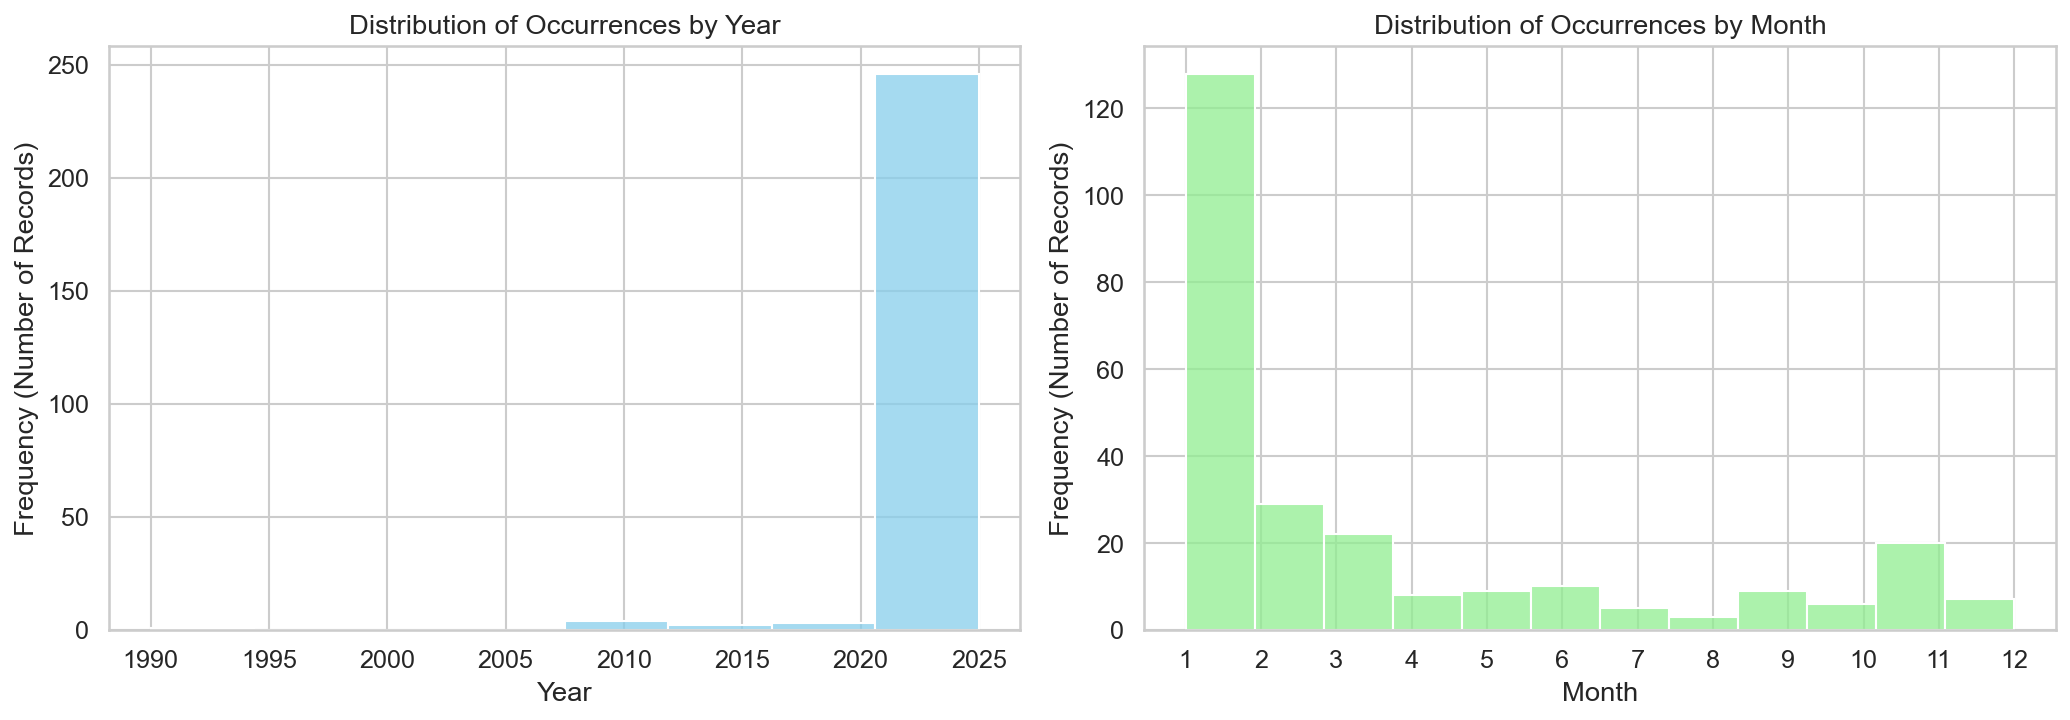

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('india_cms_final_master_enriched.csv')

# 2. Remove redundant spatial and identification columns
# Keeping 'species_scientific_name' and 'taxonomic_group' in case you want to filter later, 
# but dropping location and IDs.
columns_to_drop = [
    'latitude', 'longitude', 'country', 'state_province', 
    'occurrence_id', 'location_type', 'data_source'
]
df_temporal = df.drop(columns=columns_to_drop, errors='ignore')

# 3. Clean and parse the 'event_date'
# Convert event_date to datetime objects, coercing errors to NaT (Not a Time)
df_temporal['event_date'] = pd.to_datetime(df_temporal['event_date'], errors='coerce')

# Drop rows where we don't have a valid date, as they are useless for time-series analysis
df_temporal = df_temporal.dropna(subset=['event_date'])

# Extract clean year and month just in case the original columns had missing/float issues
df_temporal['year'] = df_temporal['event_date'].dt.year
df_temporal['month'] = df_temporal['event_date'].dt.month

# --- VISUALIZATION: Temporal Distributions ---
plt.figure(figsize=(14, 5))

# Histogram for Years
plt.subplot(1, 2, 1)
sns.histplot(df_temporal['year'], bins=len(df_temporal['year'].unique()), kde=False, color='skyblue')
plt.title('Distribution of Occurrences by Year')
plt.xlabel('Year')
plt.ylabel('Frequency (Number of Records)')

# Histogram for Months
plt.subplot(1, 2, 2)
sns.histplot(df_temporal['month'], bins=12, kde=False, color='lightgreen')
plt.title('Distribution of Occurrences by Month')
plt.xlabel('Month')
plt.ylabel('Frequency (Number of Records)')
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Make New CSV

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. LOAD DATASET ---
df = pd.read_csv('india_cms_final_master_enriched.csv')

# --- 2. REQUIRED PRE-PROCESSING ---
# a. Remove redundant spatial and identification columns
columns_to_drop = [
    'latitude', 'longitude', 'country', 'state_province', 
    'occurrence_id', 'location_type', 'data_source'
]
df_temporal = df.drop(columns=columns_to_drop, errors='ignore')

# b. Clean and parse the 'event_date'
# This coerces invalid dates to NaT (Not a Time) and drops them
df_temporal['event_date'] = pd.to_datetime(df_temporal['event_date'], errors='coerce')
df_temporal = df_temporal.dropna(subset=['event_date'])

# c. Ensure year and month are explicitly extracted 
df_temporal['year'] = df_temporal['event_date'].dt.year
df_temporal['month'] = df_temporal['event_date'].dt.month

# d. Temporal Truncation: Filter the dataset for consistent years
recent_year_threshold = 2018
df_filtered = df_temporal[df_temporal['year'] >= recent_year_threshold].copy()

# --- 3. EXPORT TO CSV ---
# Save the cleaned, truncated dataset to a new CSV file
output_filename = 'india_cms_temporal_preprocessed.csv'
df_filtered.to_csv(output_filename, index=False)

print(f"Original dataset size: {len(df)} rows")
print(f"Parsed dates dataset size: {len(df_temporal)} rows")
print(f"Truncated dataset size (>= {recent_year_threshold}): {len(df_filtered)} rows")
print(f"Data successfully saved to '{output_filename}'")

Original dataset size: 12374 rows
Parsed dates dataset size: 256 rows
Truncated dataset size (>= 2018): 249 rows
Data successfully saved to 'india_cms_temporal_preprocessed.csv'


## Decompositions


Decomposing window (80 months)...


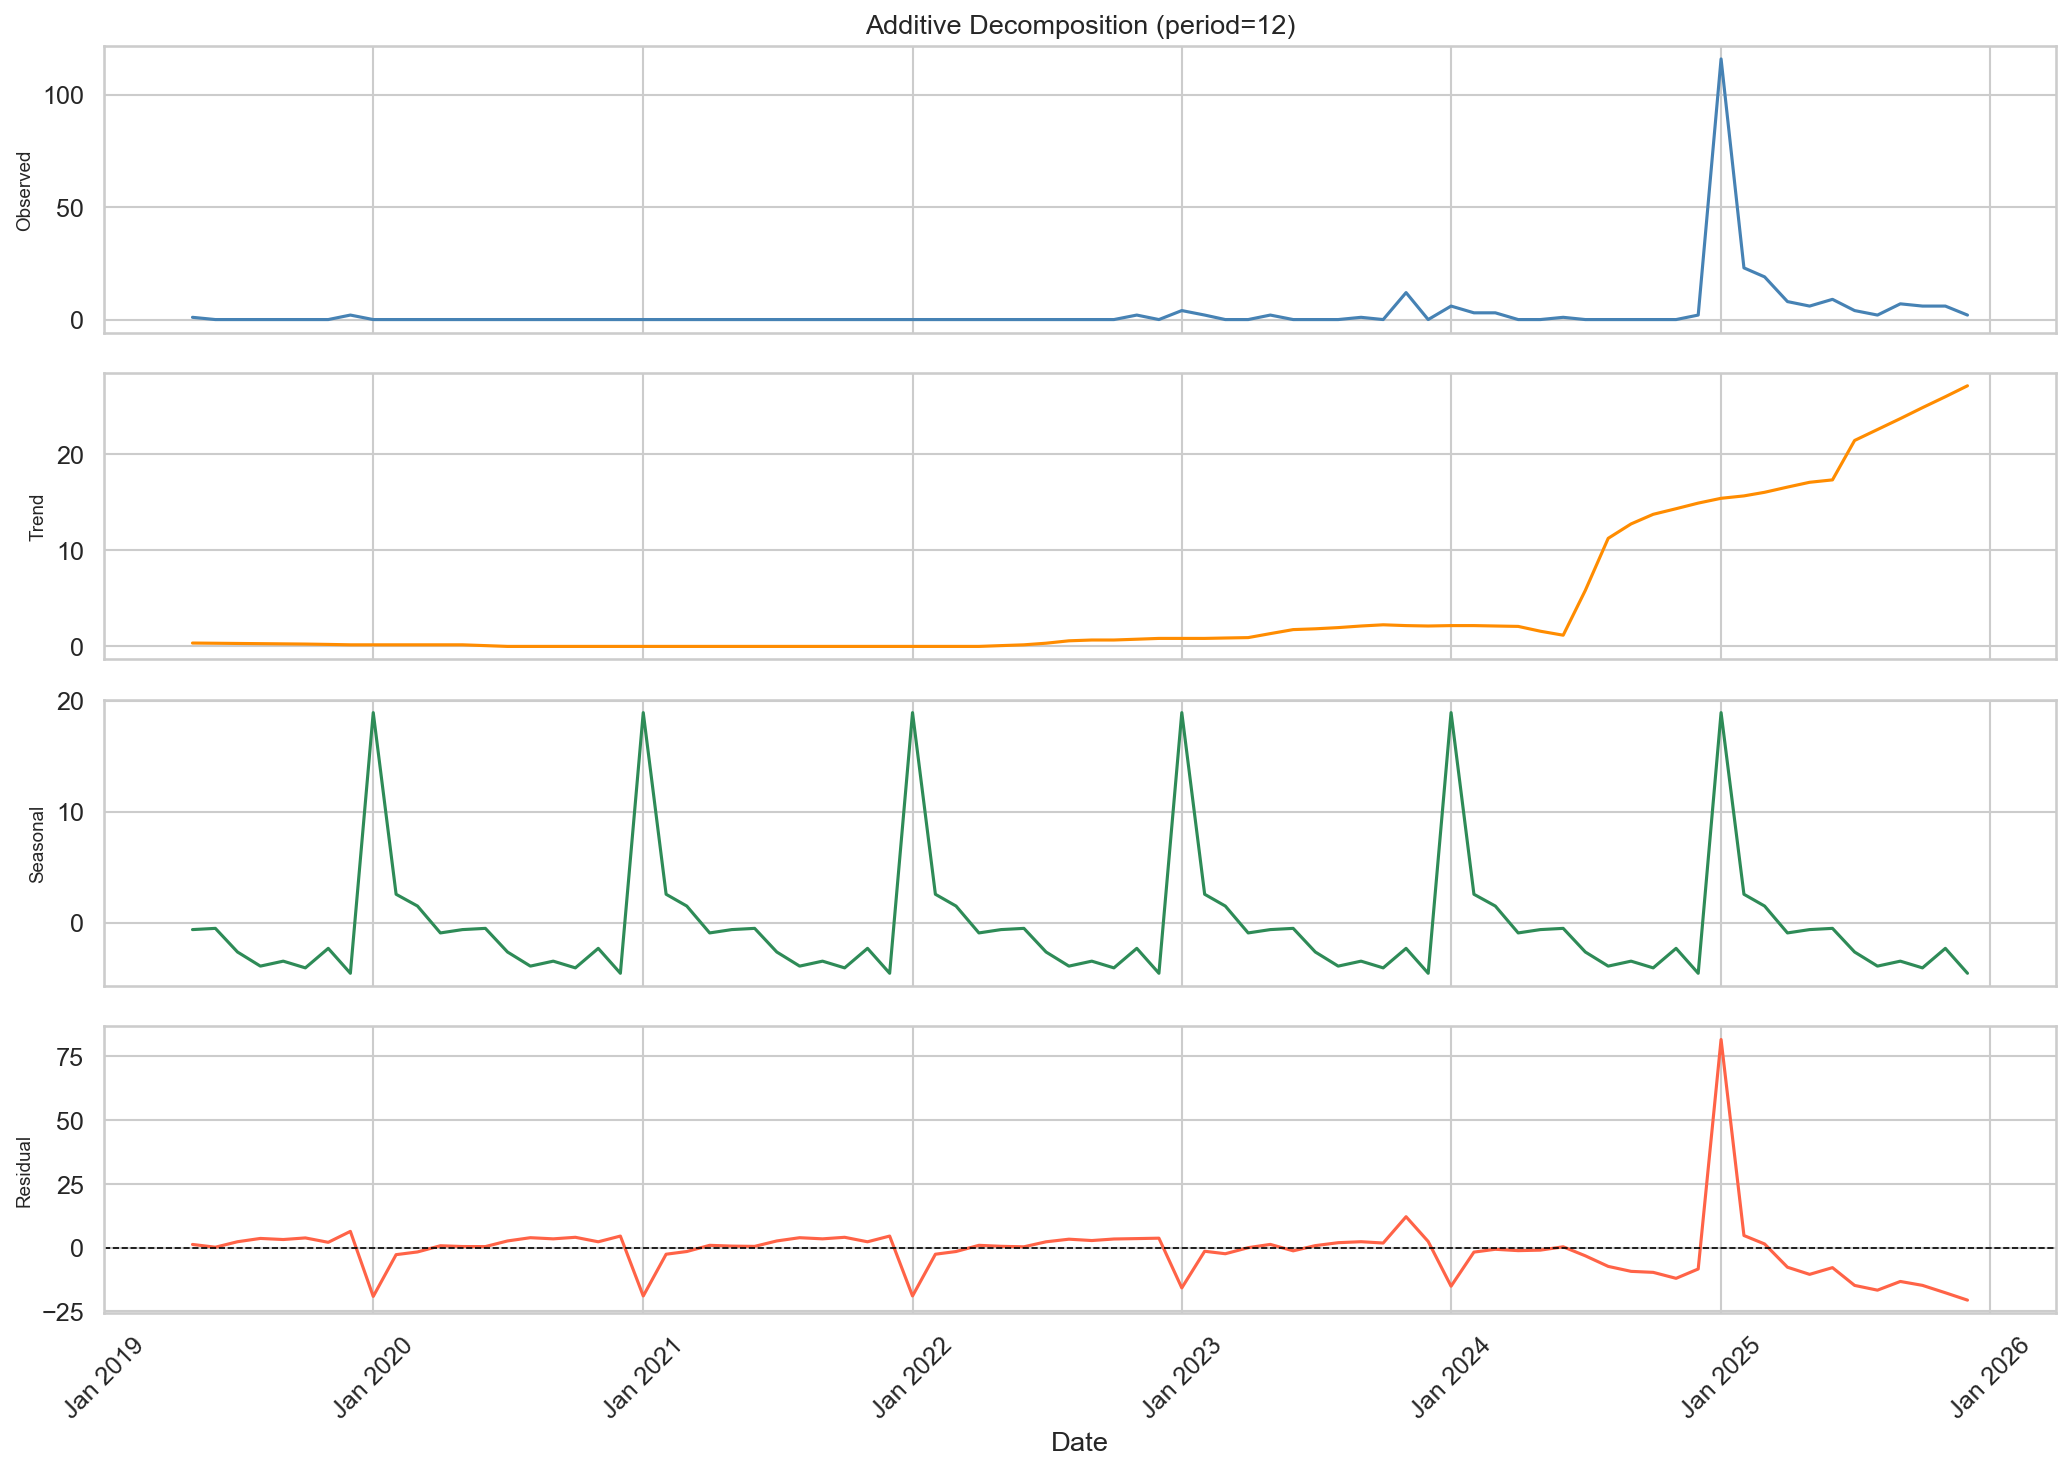

Saved: decomp_additive.png


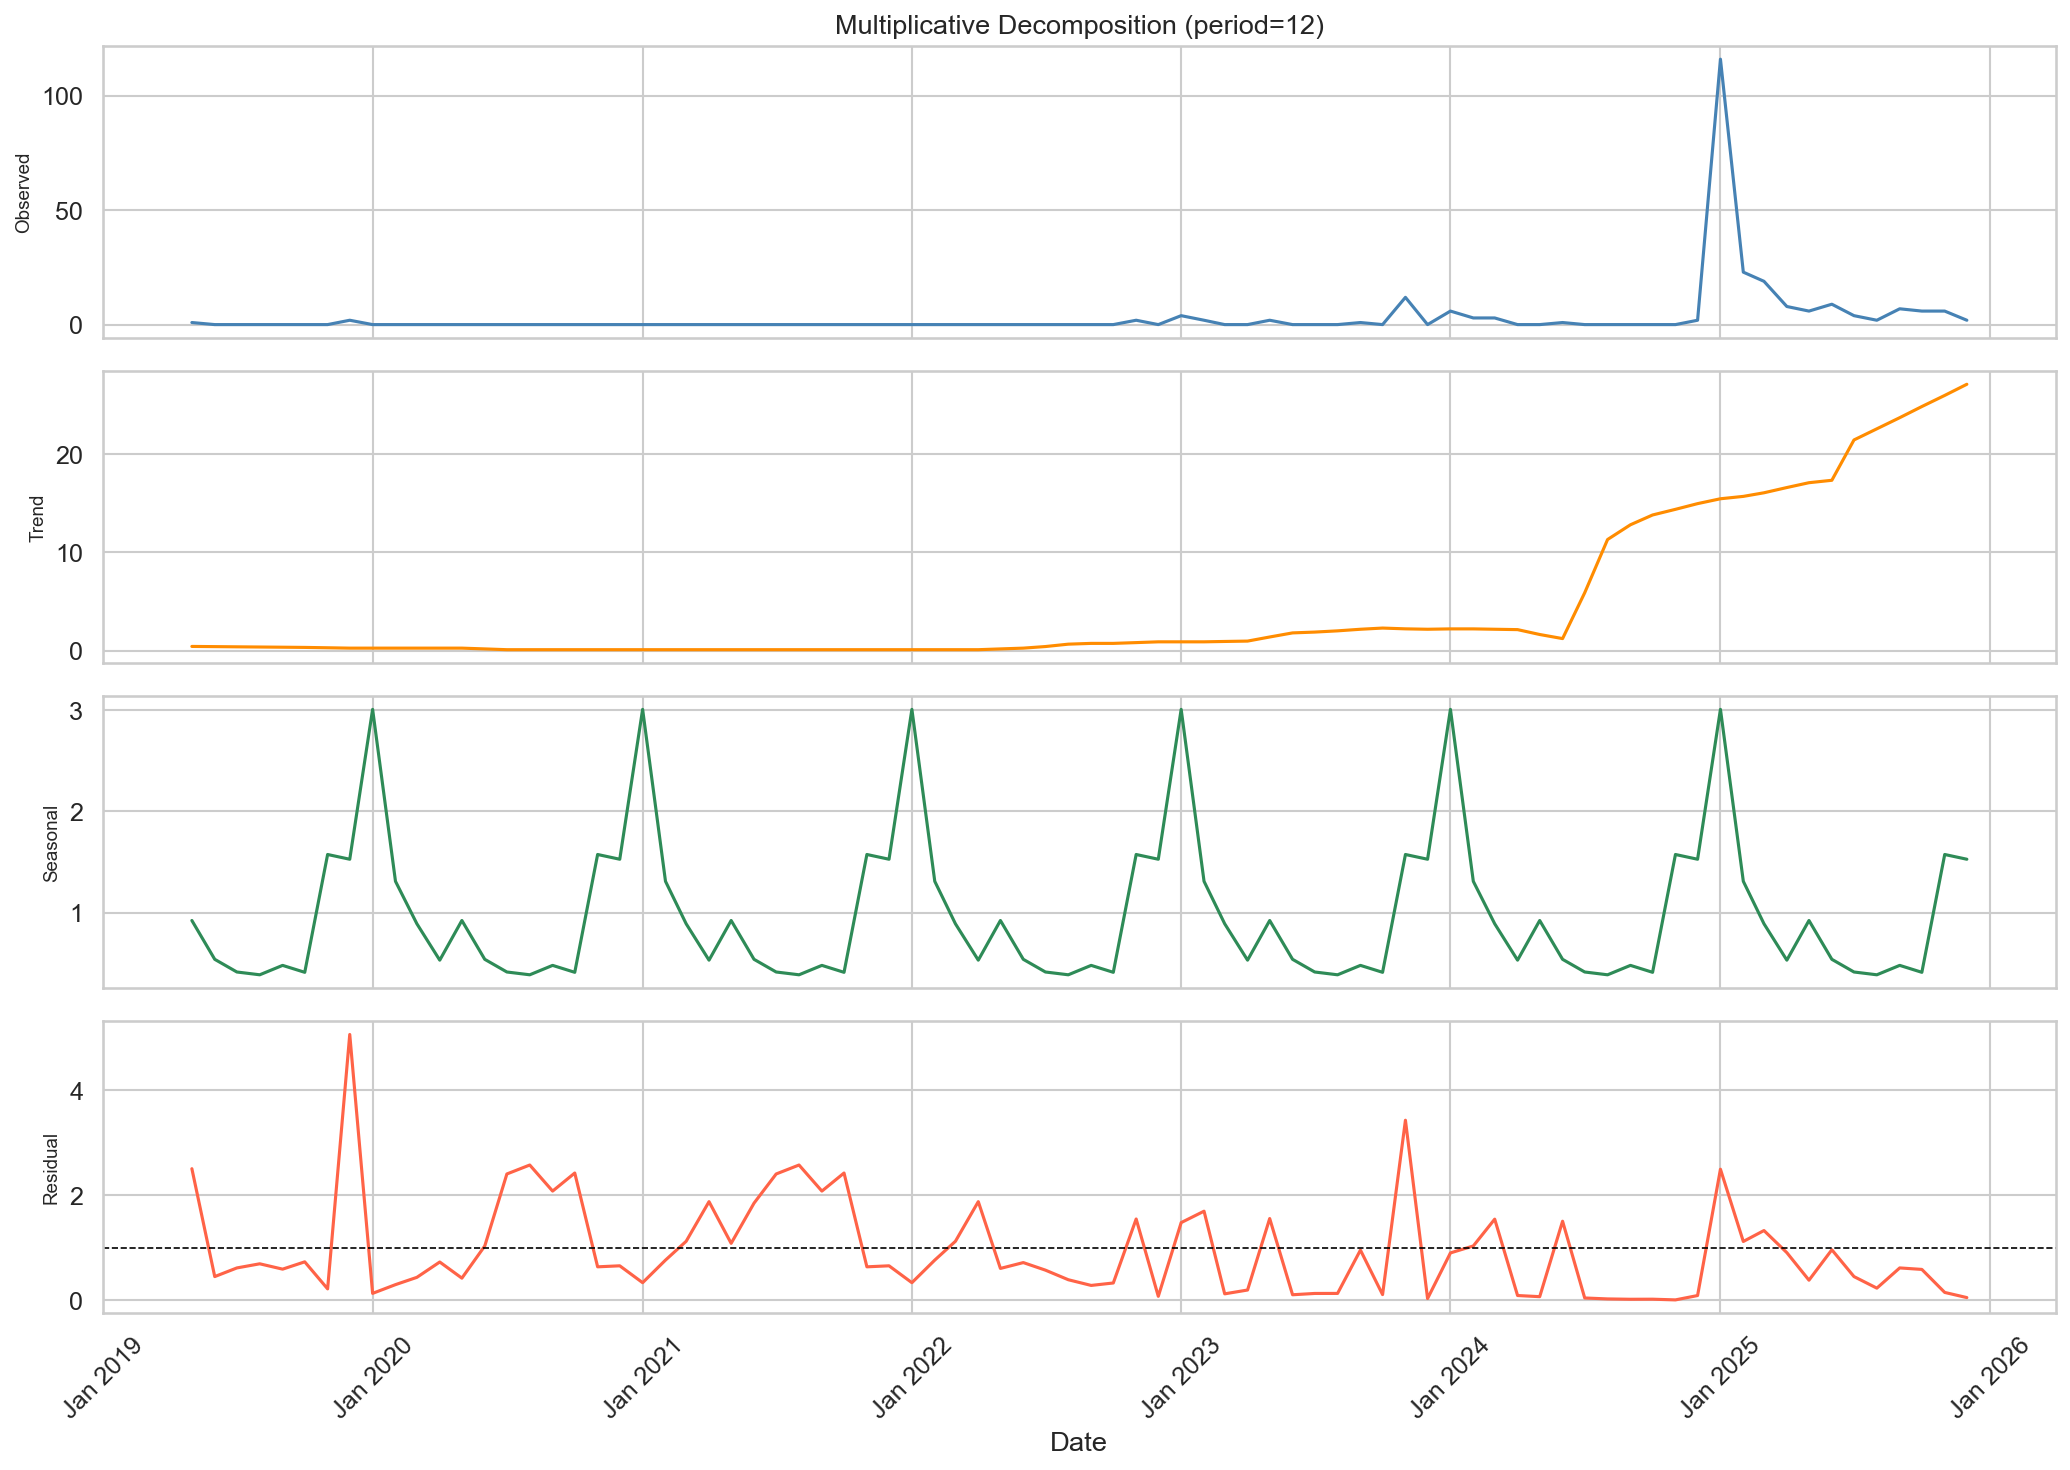

Saved: decomp_multiplicative.png

── Decomposition Variance Analysis ──
  Trend strength      : 0.2949  (0=none, 1=strong)
  Seasonality strength: 0.1999  (0=none, 1=strong)


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)

# ══════════════════════════════════════════════════════════════════════════
# 0. BUILD TIME SERIES FROM PRE-PROCESSED DATA
# ══════════════════════════════════════════════════════════════════════════
# Load the pre-processed dataset
df = pd.read_csv("india_cms_temporal_preprocessed.csv", parse_dates=['event_date'])

# Aggregate into monthly counts ('MS' = Month Start)
ts = df.set_index('event_date').resample('MS').size()

# Ensure continuous index and fill NaN with 0
ts = ts.fillna(0).astype(float)
ts.name = 'obs_count'

# Using the full pre-processed dataset (which is already >= 2018)
ts_dense = ts.copy()
print(f"\nDecomposing window ({len(ts_dense)} months)...")

# ══════════════════════════════════════════════════════════════════════════
# 7. SEASONAL DECOMPOSITION (additive + multiplicative)
# ══════════════════════════════════════════════════════════════════════════
for model_type in ['additive', 'multiplicative']:
    try:
        s = ts_dense.copy()
        if model_type == 'multiplicative':
            s = s.replace(0, 0.1)   # multiplicative needs strictly positive values

        decomp = seasonal_decompose(s, model=model_type,
                                     period=12, extrapolate_trend='freq')
        fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
        label_map = [('Observed', s, 'steelblue'),
                     ('Trend',    decomp.trend,    'darkorange'),
                     ('Seasonal', decomp.seasonal, 'seagreen'),
                     ('Residual', decomp.resid,    'tomato')]
        for ax, (comp_label, comp, color) in zip(axes, label_map):
            ax.plot(comp, color=color, linewidth=1.5)
            ax.set_ylabel(comp_label, fontsize=9)
            if comp_label == 'Residual':
                base = 0 if model_type == 'additive' else 1
                ax.axhline(base, color='black', linestyle='--', linewidth=0.8)

        suffix  = 'a' if model_type == 'additive' else 'b'
        title_s = model_type.capitalize()
        axes[0].set_title(f'{title_s} Decomposition (period=12)',
                          fontsize=13)
        axes[-1].set_xlabel('Date')
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        fname = f'decomp_{model_type}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {fname}")
    except Exception as e:
        print(f"Decomposition ({model_type}) failed: {e}")

# ══════════════════════════════════════════════════════════════════════════
# 8. SEASONALITY & TREND STRENGTH (variance ratio)
# ══════════════════════════════════════════════════════════════════════════
try:
    decomp_add = seasonal_decompose(ts_dense, model='additive',
                                     period=12, extrapolate_trend='freq')
    var_s = np.var(decomp_add.seasonal)
    var_r = np.var(decomp_add.resid.dropna())
    var_t = np.var(decomp_add.trend.dropna())
    s_strength = max(0, 1 - var_r / (var_s + var_r))
    t_strength = max(0, 1 - var_r / (var_t + var_r))
    print(f"\n── Decomposition Variance Analysis ──")
    print(f"  Trend strength      : {t_strength:.4f}  (0=none, 1=strong)")
    print(f"  Seasonality strength: {s_strength:.4f}  (0=none, 1=strong)")
except Exception as e:
    print(f"Variance analysis failed: {e}")

# Task 2: Temporal Autocorrelation and Stationarity

## Temporal Autocorrelation

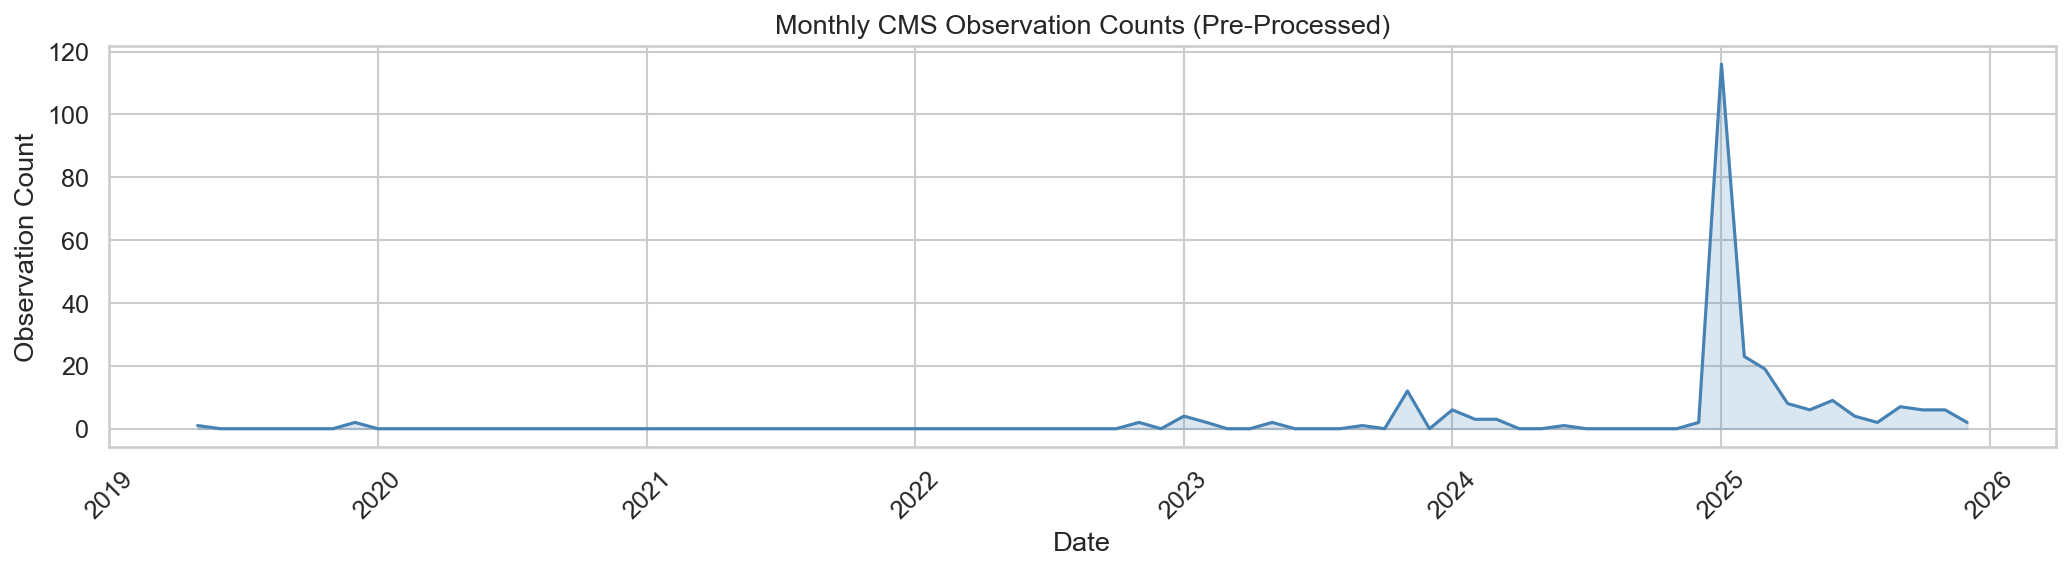

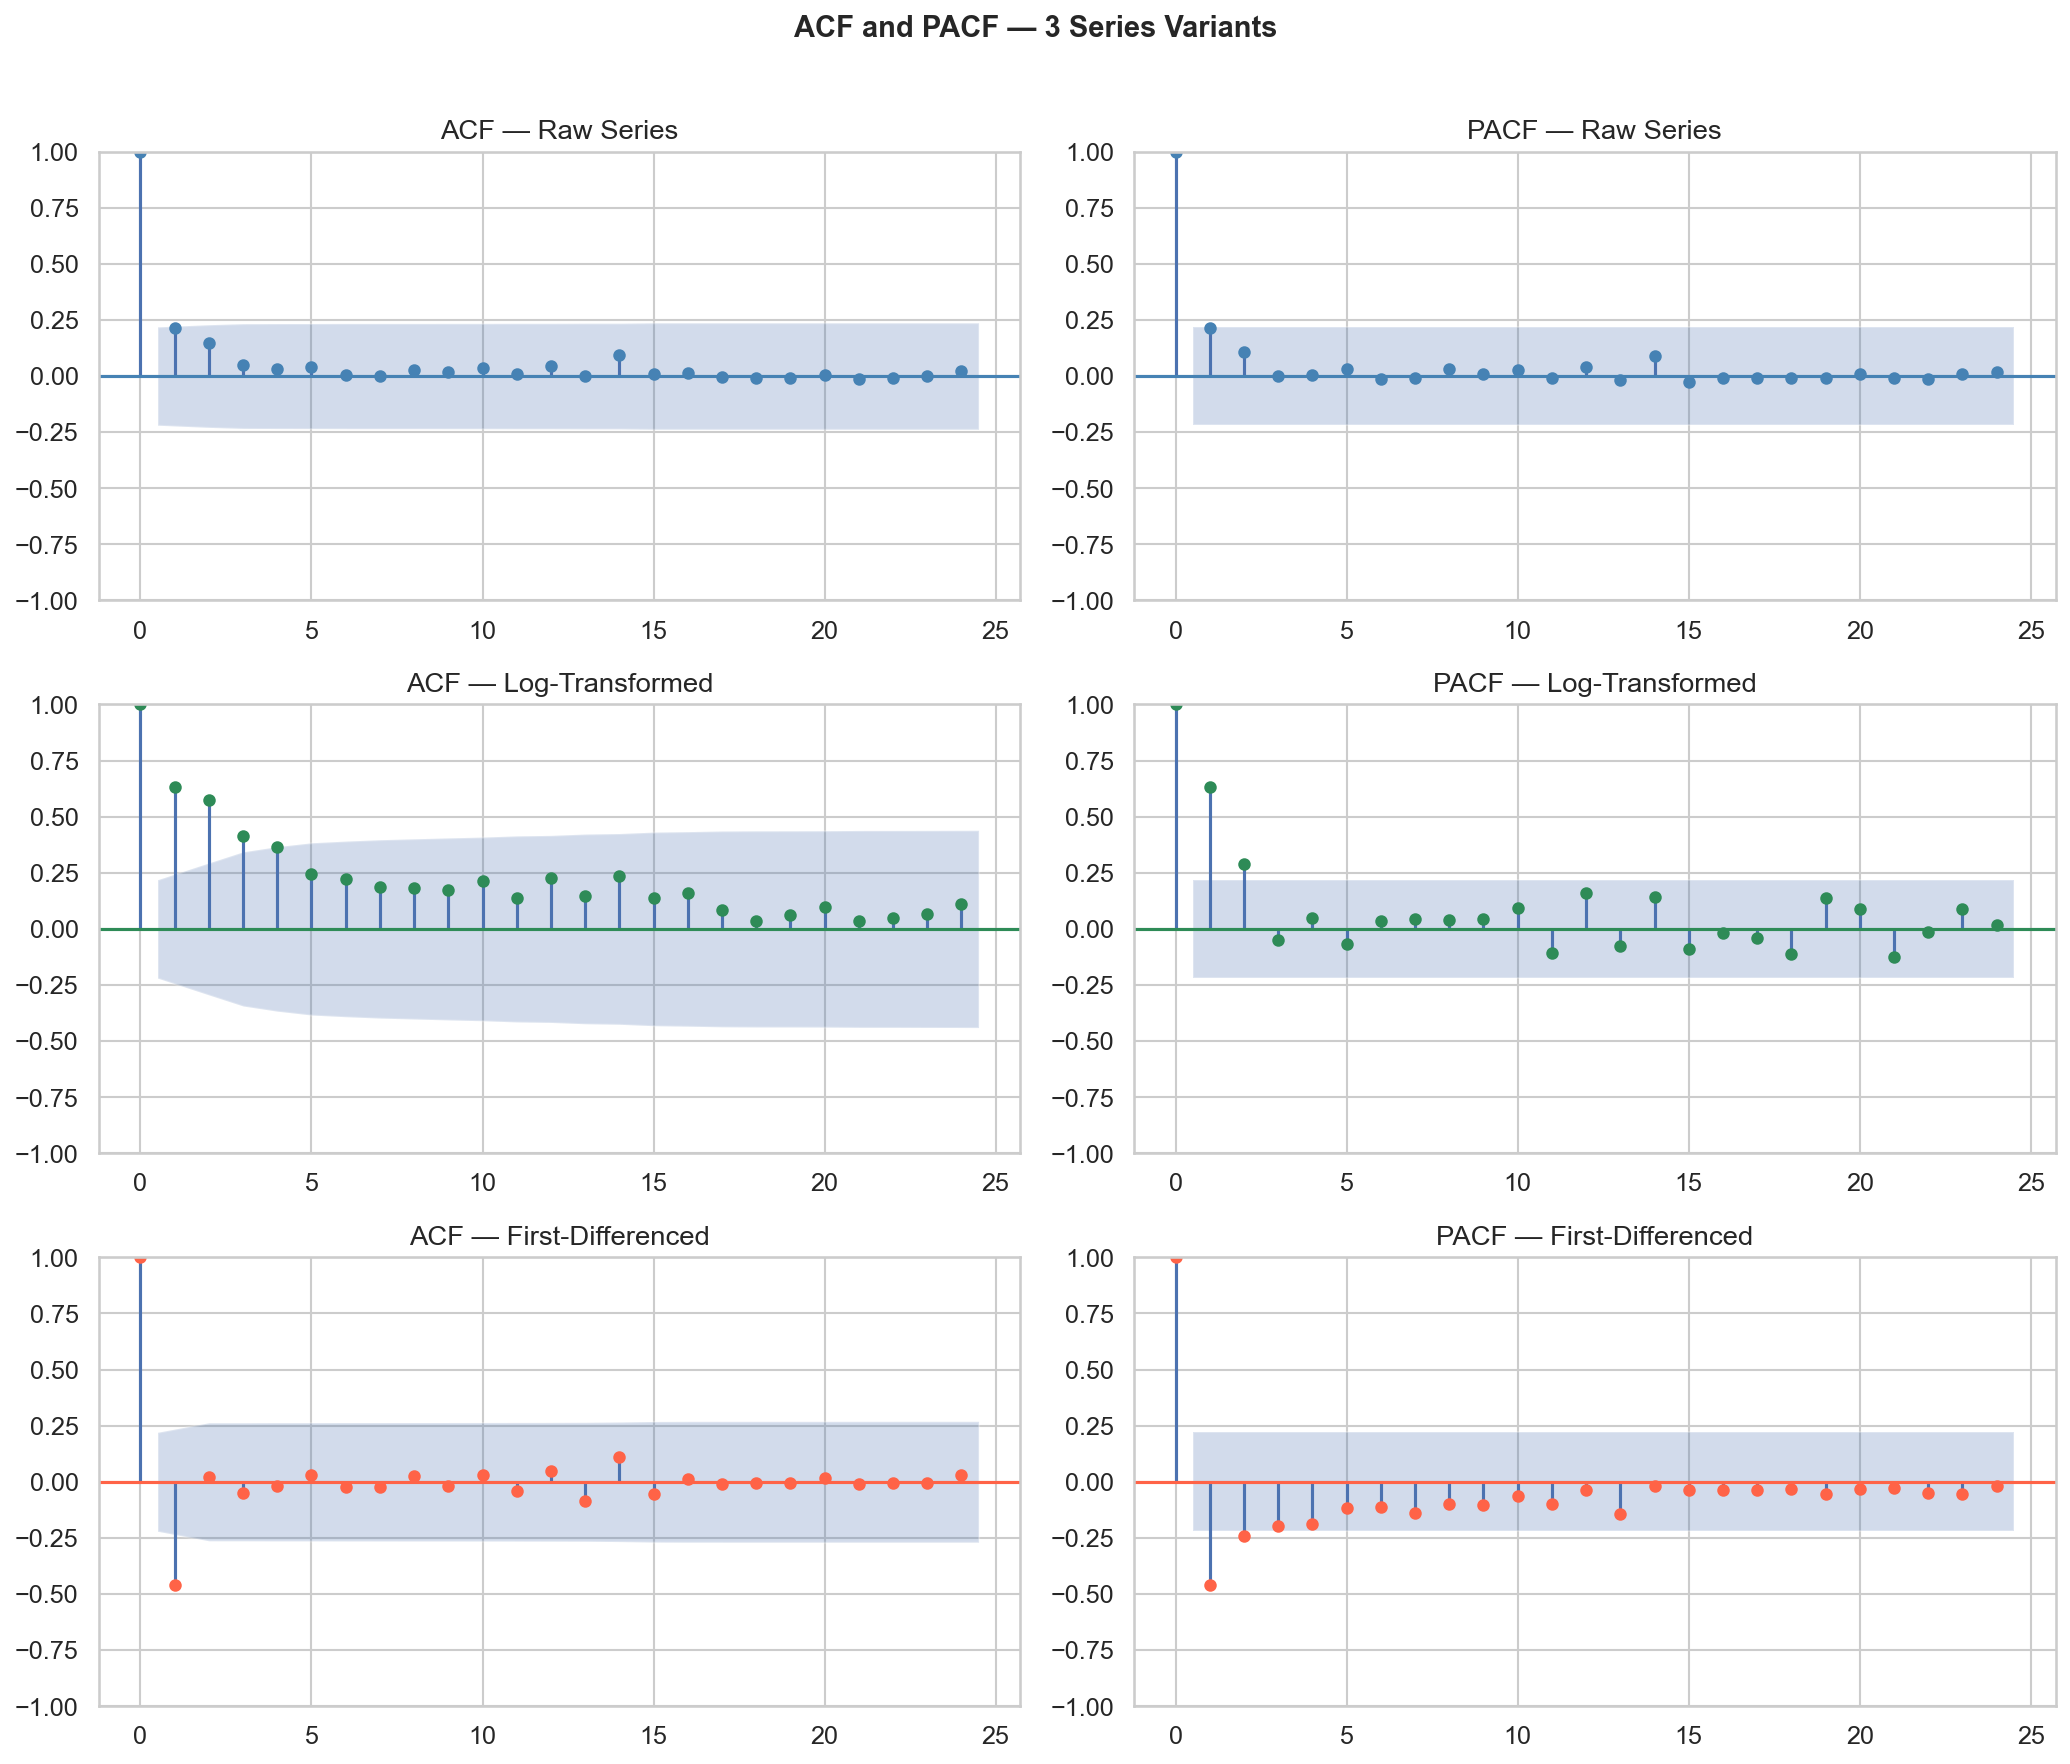

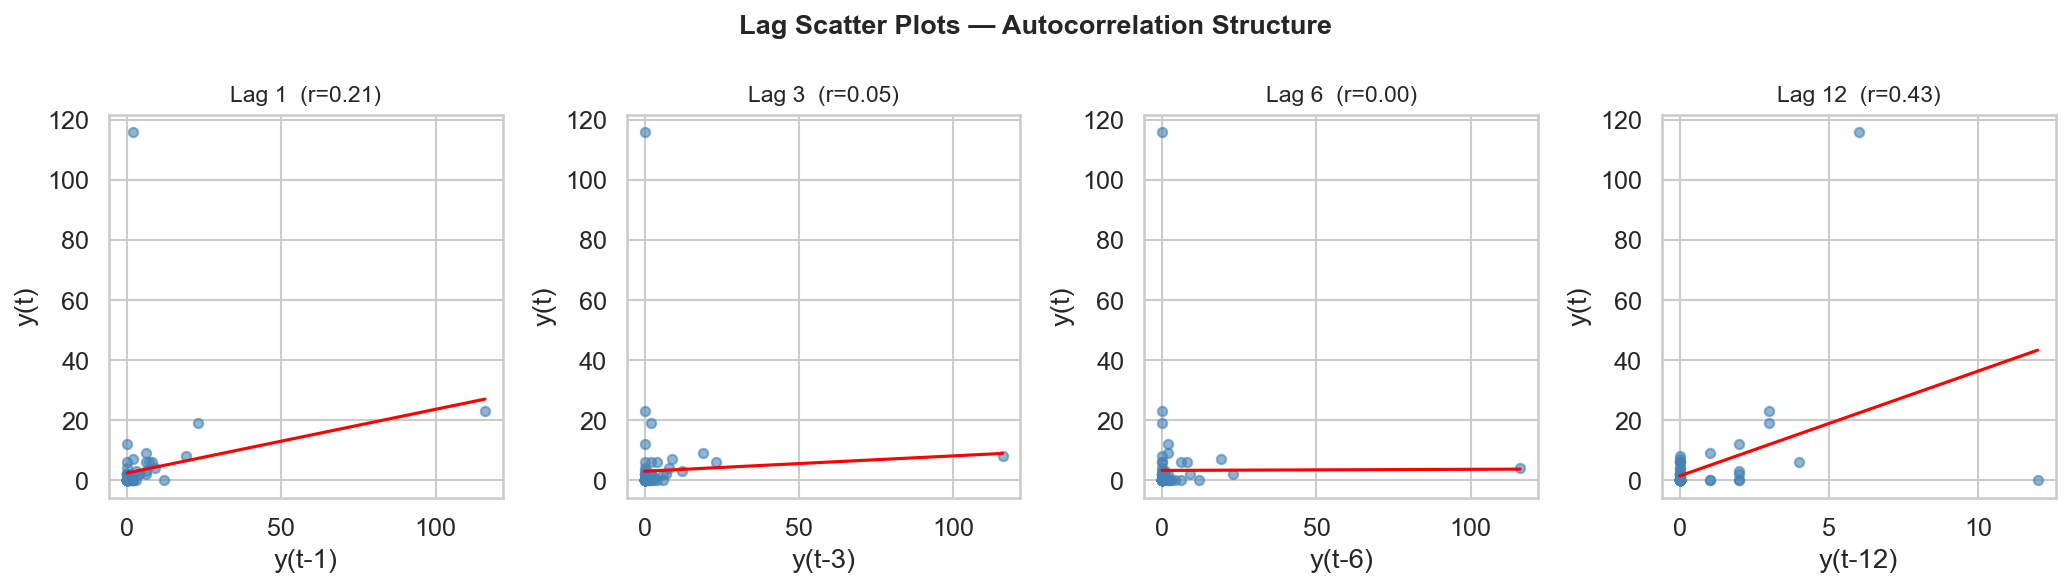

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)

# ══════════════════════════════════════════════════════════════════════════
# 0. DATA PREPARATION
# ══════════════════════════════════════════════════════════════════════════
df = pd.read_csv("india_cms_temporal_preprocessed.csv", parse_dates=['event_date'])
ts = df.set_index('event_date').resample('MS').size().fillna(0).astype(float)
ts.name = 'obs_count'

# Create transformations
ts_log = np.log1p(ts)
ts_d1 = ts.diff().dropna()

# ══════════════════════════════════════════════════════════════════════════
# 1. RAW TIME SERIES
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(ts.index, ts.values, alpha=0.2, color='steelblue')
ax.plot(ts.index, ts.values, color='steelblue', linewidth=1.5)
ax.set_title('Monthly CMS Observation Counts (Pre-Processed)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Observation Count')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# 2. ACF AND PACF PLOTS (Raw, Log, First-Diff ONLY)
# ══════════════════════════════════════════════════════════════════════════
acf_variants = [
    (ts,      'Raw Series',          'steelblue'),
    (ts_log,  'Log-Transformed',     'seagreen'),
    (ts_d1,   'First-Differenced',   'tomato'),
]

MAX_LAGS = min(24, len(ts) // 2 - 1)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row, (series, label, color) in enumerate(acf_variants):
    plot_acf (series.dropna(), lags=MAX_LAGS, ax=axes[row, 0], title=f'ACF — {label}', color=color)
    plot_pacf(series.dropna(), lags=MAX_LAGS, ax=axes[row, 1], title=f'PACF — {label}', method='ywm', color=color)

fig.suptitle('ACF and PACF — 3 Series Variants', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# 3. LAG SCATTER PLOTS
# ══════════════════════════════════════════════════════════════════════════
lag_list = [1, 3, 6, 12]
fig, axes = plt.subplots(1, len(lag_list), figsize=(14, 4))

for ax, lag in zip(axes, lag_list):
    if lag < len(ts):
        x = ts.values[:-lag]
        y = ts.values[lag:]
        ax.scatter(x, y, alpha=0.6, s=20, color='steelblue')
        m, b, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        ax.plot(xline, m * xline + b, color='red', linewidth=1.5)
        ax.set_title(f'Lag {lag}  (r={r:.2f})', fontsize=11)
        ax.set_xlabel(f'y(t-{lag})')
        ax.set_ylabel('y(t)')

fig.suptitle('Lag Scatter Plots — Autocorrelation Structure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Stationarity Analysis

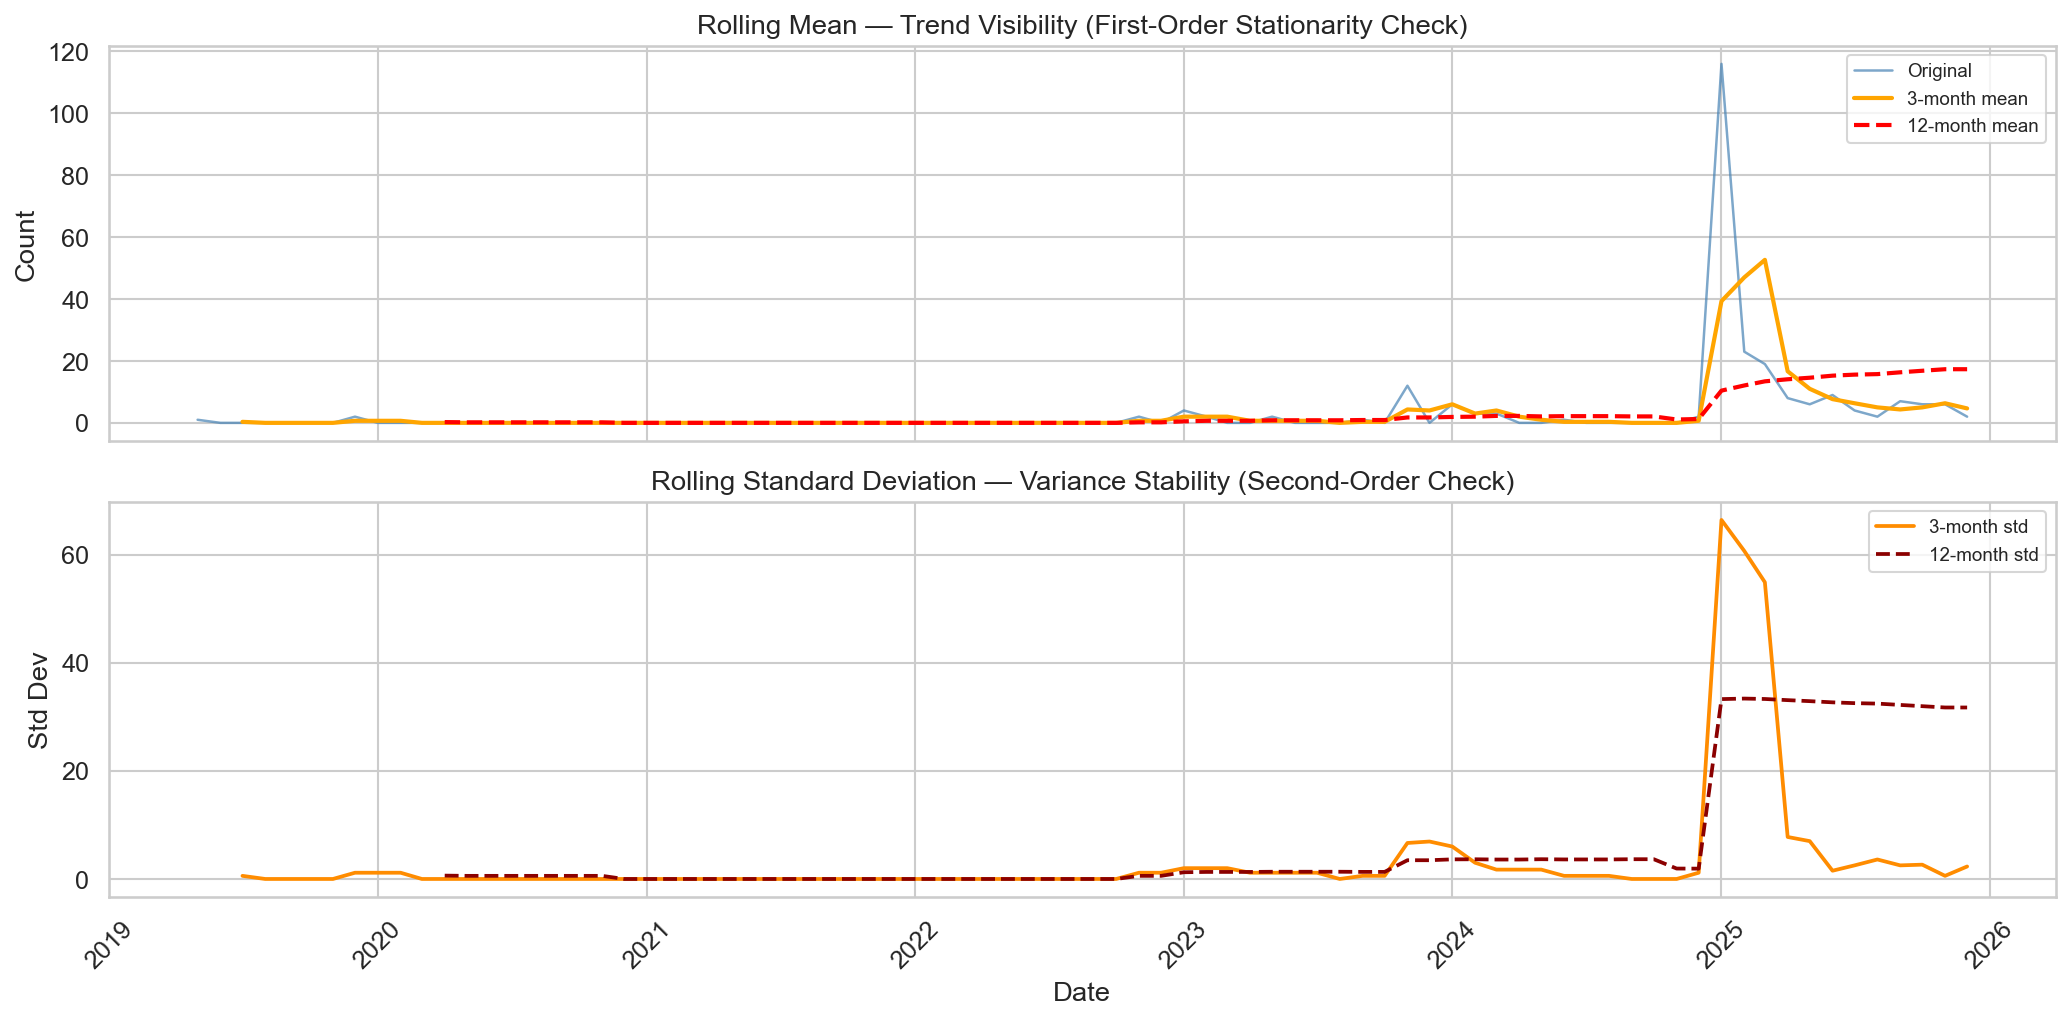


═════════════════════════════════════════════════════════════════
DIAGNOSTICS FOR: RAW SERIES
═════════════════════════════════════════════════════════════════

1. FIRST-ORDER STATIONARITY (Mean Stability Check)
   Mean of Half 1: 0.0750
   Mean of Half 2: 6.1500
   T-Test p-value: 0.04481
   Conclusion: FAILED. The mean changes significantly over time (Trend present).

2. SECOND-ORDER (WEAK) STATIONARITY (Variance & Root Checks)
   Variance of Half 1: 0.1194
   Variance of Half 2: 334.7775
   Levene's Test for Equal Variance p-value: 0.04258
   -> Variance changes over time (Heteroskedasticity present).

   ADF Test p-value:  0.00000 (< 0.05 implies stationary)
   KPSS Test p-value: 0.04596 (> 0.05 implies stationary)
   Conclusion: PARTIAL PASS. Data is stationary enough for ARIMA (ADF passed).

3. STRICT STATIONARITY (Distributional Stability Check)
   Kolmogorov-Smirnov Test p-value: 0.00002
   Conclusion: FAILED. The underlying distribution changes significantly.

═══════════════

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)

# ══════════════════════════════════════════════════════════════════════════
# 0. DATA PREPARATION
# ══════════════════════════════════════════════════════════════════════════
df = pd.read_csv("india_cms_temporal_preprocessed.csv", parse_dates=['event_date'])
ts = df.set_index('event_date').resample('MS').size().fillna(0).astype(float)
ts.name = 'Raw Series'

# ══════════════════════════════════════════════════════════════════════════
# 1. ROLLING STATISTICS (Visual Stationarity Check)
# ══════════════════════════════════════════════════════════════════════════
roll3       = ts.rolling(window=3).mean()
roll12      = ts.rolling(window=12).mean()
roll3_std   = ts.rolling(window=3).std()
roll12_std  = ts.rolling(window=12).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top plot: Rolling Mean (First-Order Visual Check)
ax1.plot(ts,     label='Original',      color='steelblue', linewidth=1.2, alpha=0.7)
ax1.plot(roll3,  label='3-month mean',  color='orange',    linewidth=2)
ax1.plot(roll12, label='12-month mean', color='red',       linewidth=2, linestyle='--')
ax1.set_ylabel('Count')
ax1.set_title('Rolling Mean — Trend Visibility (First-Order Stationarity Check)')
ax1.legend(fontsize=9)

# Bottom plot: Rolling Std Deviation (Second-Order Variance Visual Check)
ax2.plot(roll3_std,  label='3-month std',  color='darkorange', linewidth=1.8)
ax2.plot(roll12_std, label='12-month std', color='darkred',    linewidth=1.8, linestyle='--')
ax2.set_ylabel('Std Dev')
ax2.set_xlabel('Date')
ax2.set_title('Rolling Standard Deviation — Variance Stability (Second-Order Check)')
ax2.legend(fontsize=9)

ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# 2. TRANSFORMATIONS
# ══════════════════════════════════════════════════════════════════════════
ts_log = np.log1p(ts)
ts_log.name = 'Log-Transformed Series'

ts_d1 = ts.diff().dropna()
ts_d1.name = 'First-Differenced Series'

series_variants = [ts, ts_log, ts_d1]

# ══════════════════════════════════════════════════════════════════════════
# 3. DIAGNOSTICS FUNCTION
# ══════════════════════════════════════════════════════════════════════════
def run_stationarity_diagnostics(series):
    # Clean data and split into halves
    ts_clean = series.dropna().values
    split = len(ts_clean) // 2
    part1, part2 = ts_clean[:split], ts_clean[split:]
    
    print(f"\n{'═' * 65}")
    print(f"DIAGNOSTICS FOR: {series.name.upper()}")
    print(f"{'═' * 65}")

    # ----------------------------------------------------------------------
    # 1. FIRST-ORDER STATIONARITY (Mean Stability Check)
    # ----------------------------------------------------------------------
    t_stat, p_val_mean = stats.ttest_ind(part1, part2, equal_var=False)

    print("\n1. FIRST-ORDER STATIONARITY (Mean Stability Check)")
    print(f"   Mean of Half 1: {part1.mean():.4f}")
    print(f"   Mean of Half 2: {part2.mean():.4f}")
    print(f"   T-Test p-value: {p_val_mean:.5f}")
    if p_val_mean > 0.05:
        print("   Conclusion: PASSED. The mean is statistically constant over time.")
    else:
        print("   Conclusion: FAILED. The mean changes significantly over time (Trend present).")

    # ----------------------------------------------------------------------
    # 2. SECOND-ORDER / WEAK STATIONARITY (Variance & Unit Root Checks)
    # ----------------------------------------------------------------------
    # a) Variance Stability Check (Levene's Test)
    stat_var, p_val_var = stats.levene(part1, part2)

    # b) Autocovariance / Unit Root Check (ADF & KPSS)
    adf_res = adfuller(ts_clean)
    kpss_res = kpss(ts_clean, regression='c', nlags='auto')

    print("\n2. SECOND-ORDER (WEAK) STATIONARITY (Variance & Root Checks)")
    print(f"   Variance of Half 1: {part1.var():.4f}")
    print(f"   Variance of Half 2: {part2.var():.4f}")
    print(f"   Levene's Test for Equal Variance p-value: {p_val_var:.5f}")
    if p_val_var > 0.05:
        print("   -> Variance is stable over time.")
    else:
        print("   -> Variance changes over time (Heteroskedasticity present).")

    print(f"\n   ADF Test p-value:  {adf_res[1]:.5f} (< 0.05 implies stationary)")
    print(f"   KPSS Test p-value: {kpss_res[1]:.5f} (> 0.05 implies stationary)")

    if adf_res[1] < 0.05 and kpss_res[1] > 0.05:
        print("   Conclusion: PASSED. The series is strictly Second-Order Stationary.")
    elif adf_res[1] < 0.05:
        print("   Conclusion: PARTIAL PASS. Data is stationary enough for ARIMA (ADF passed).")
    elif kpss_res[1] > 0.05:
        print("   Conclusion: PARTIAL PASS. Mean/variance stationary, but unit root suspected.")
    else:
        print("   Conclusion: FAILED. Series requires further differencing (d > 0).")

    # ----------------------------------------------------------------------
    # 3. STRICT STATIONARITY (Distributional Stability Check)
    # ----------------------------------------------------------------------
    ks_stat, p_val_ks = stats.ks_2samp(part1, part2)

    print("\n3. STRICT STATIONARITY (Distributional Stability Check)")
    print(f"   Kolmogorov-Smirnov Test p-value: {p_val_ks:.5f}")
    if p_val_ks > 0.05:
        print("   Conclusion: PASSED. The underlying joint distribution is invariant.")
    else:
        print("   Conclusion: FAILED. The underlying distribution changes significantly.")

# ══════════════════════════════════════════════════════════════════════════
# 4. RUN TESTS
# ══════════════════════════════════════════════════════════════════════════
for series in series_variants:
    run_stationarity_diagnostics(series)

# Task 3: Temporal Regression Models

Training Series: 2019-05-31 to 2024-12-31
Testing Series : 2025-01-31 to 2025-12-31

Running Grid Search for Optimal SARIMA...
Best SARIMA Order: (1, 1, 1) x (0, 1, 1, 12)

--- PERFORMANCE ON UNSEEN 12-MONTH HOLDOUT ---
Linear Model -> MAE: 16.45 | RMSE: 34.28 | R²: -0.2743
SARIMA Model -> MAE: 16.97 | RMSE: 34.64 | R²: -0.3010


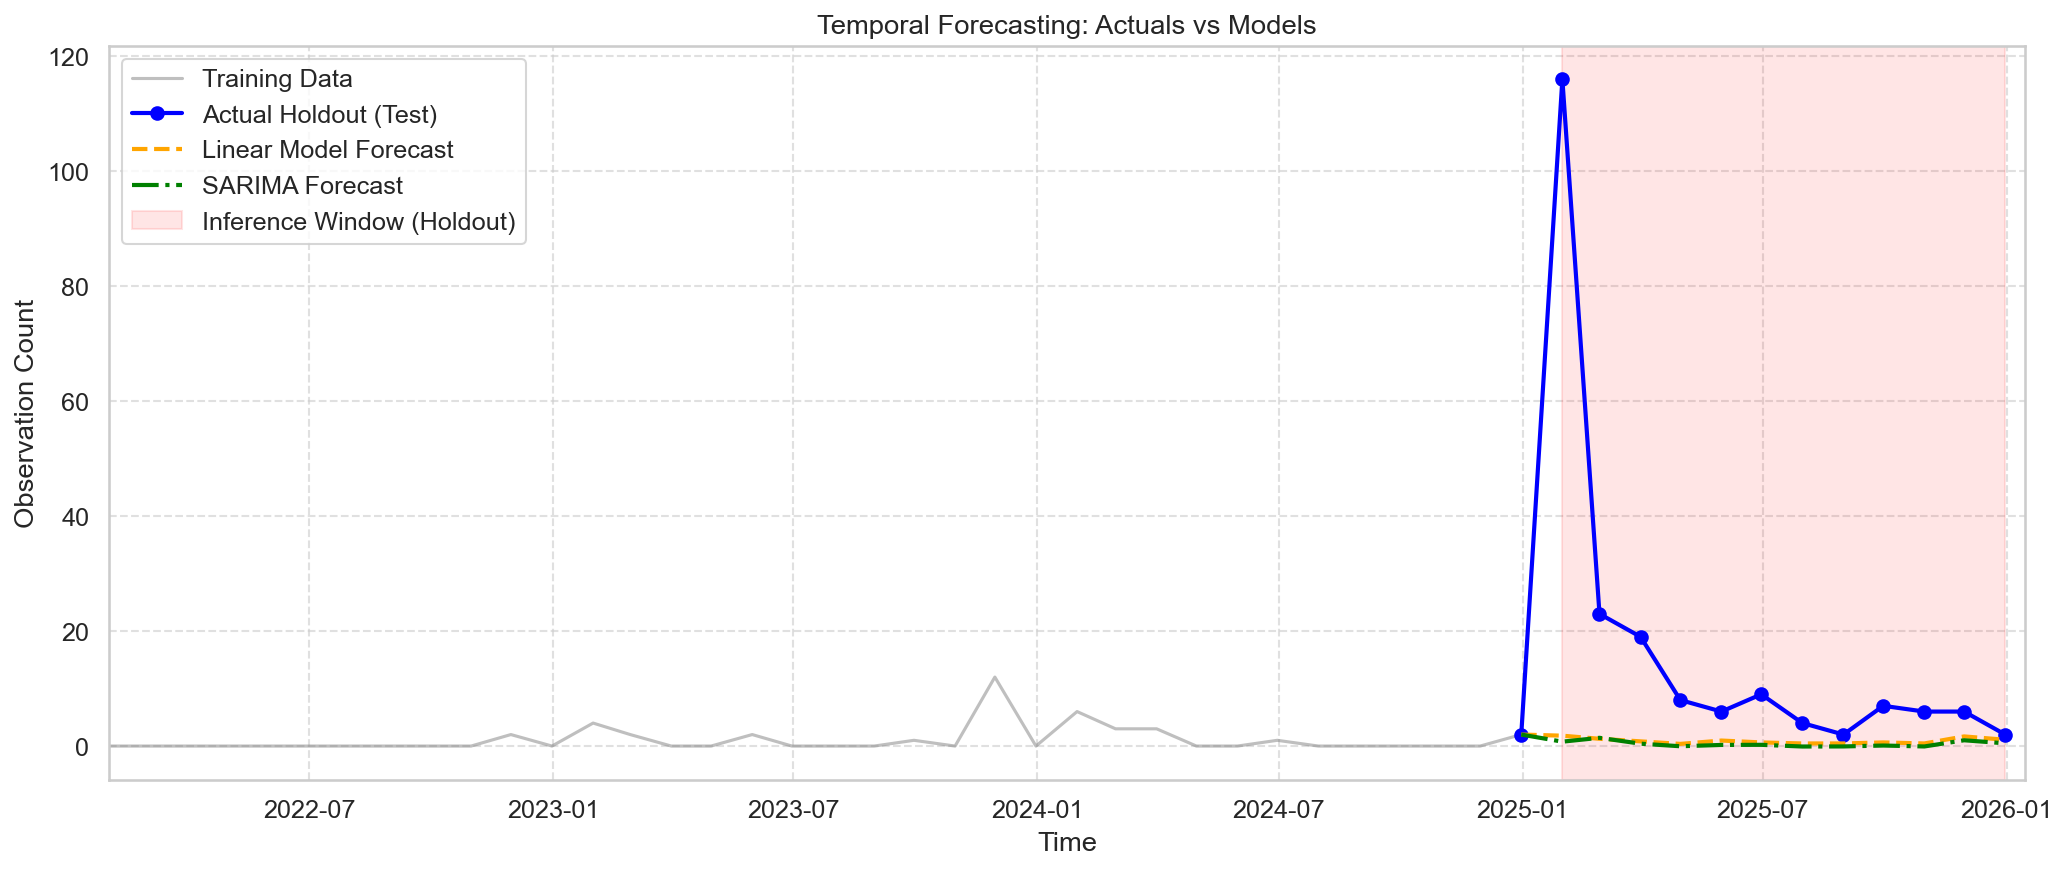

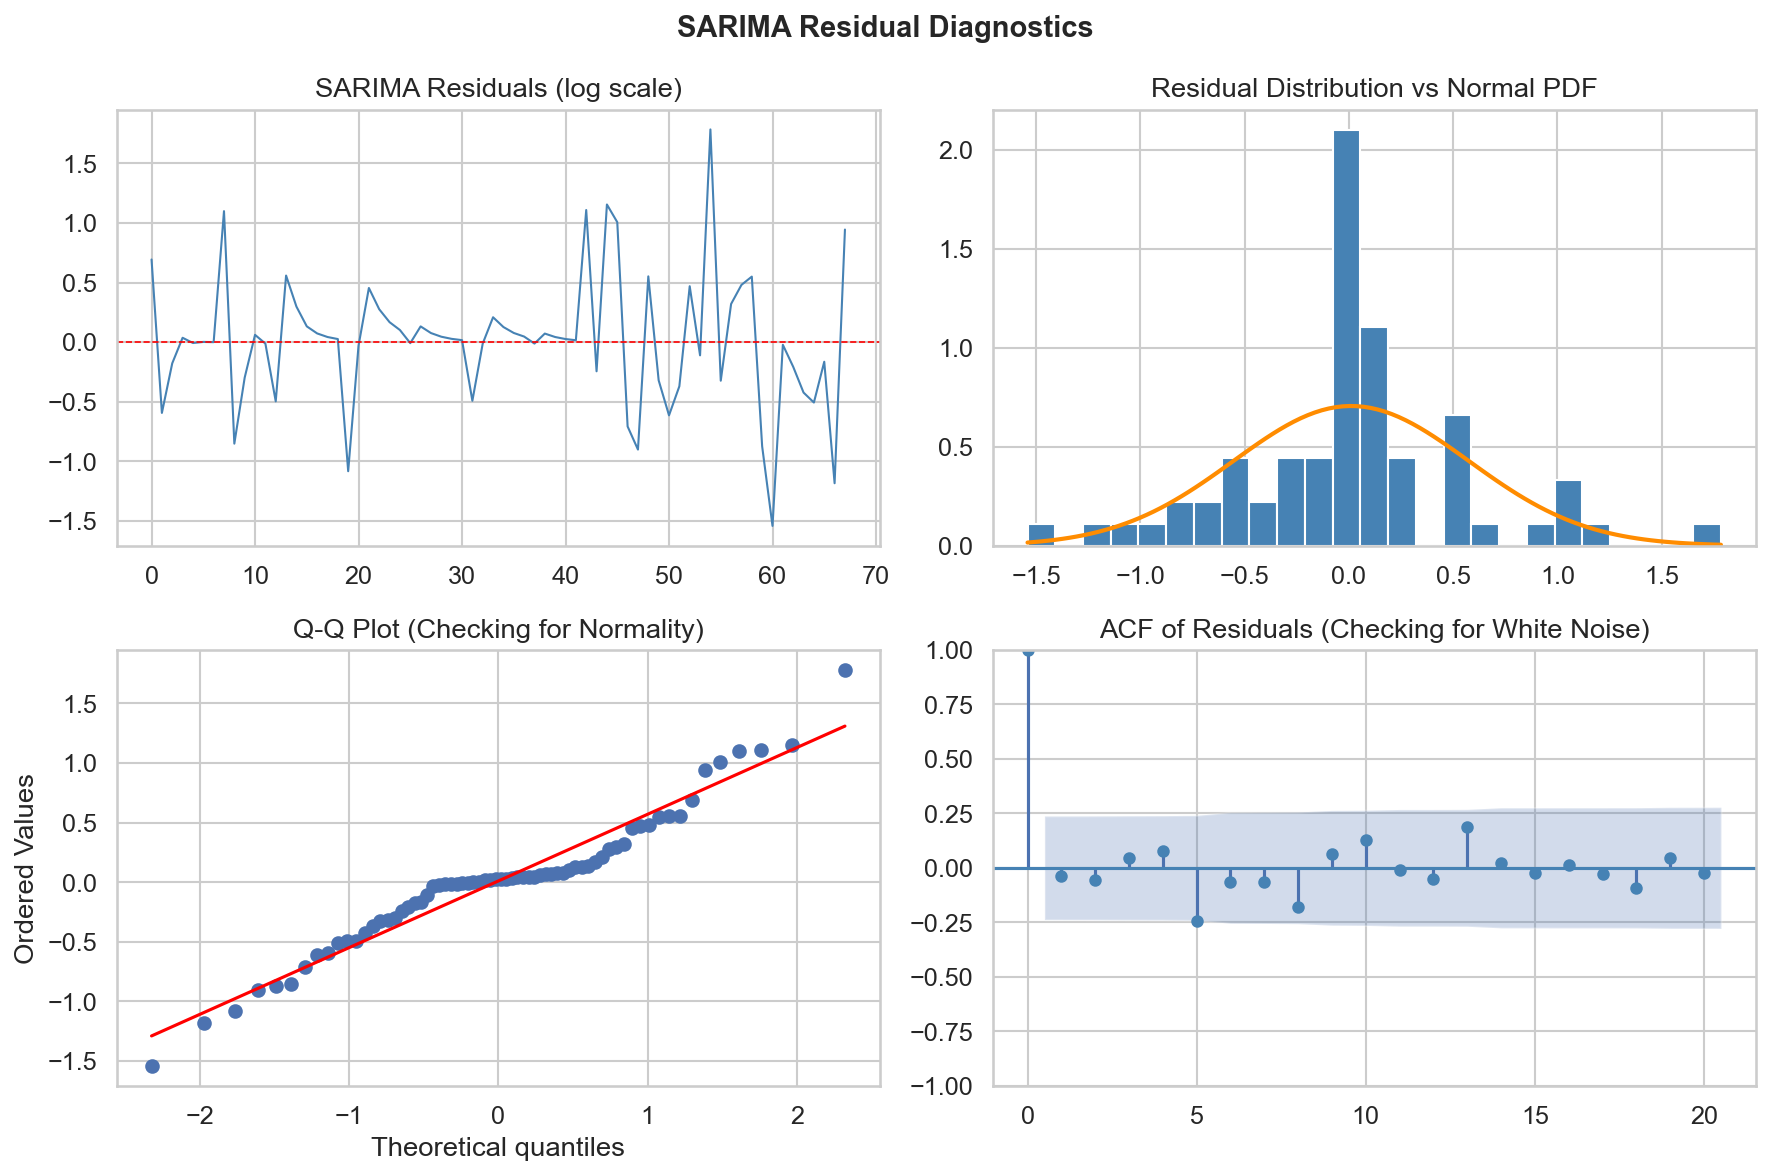

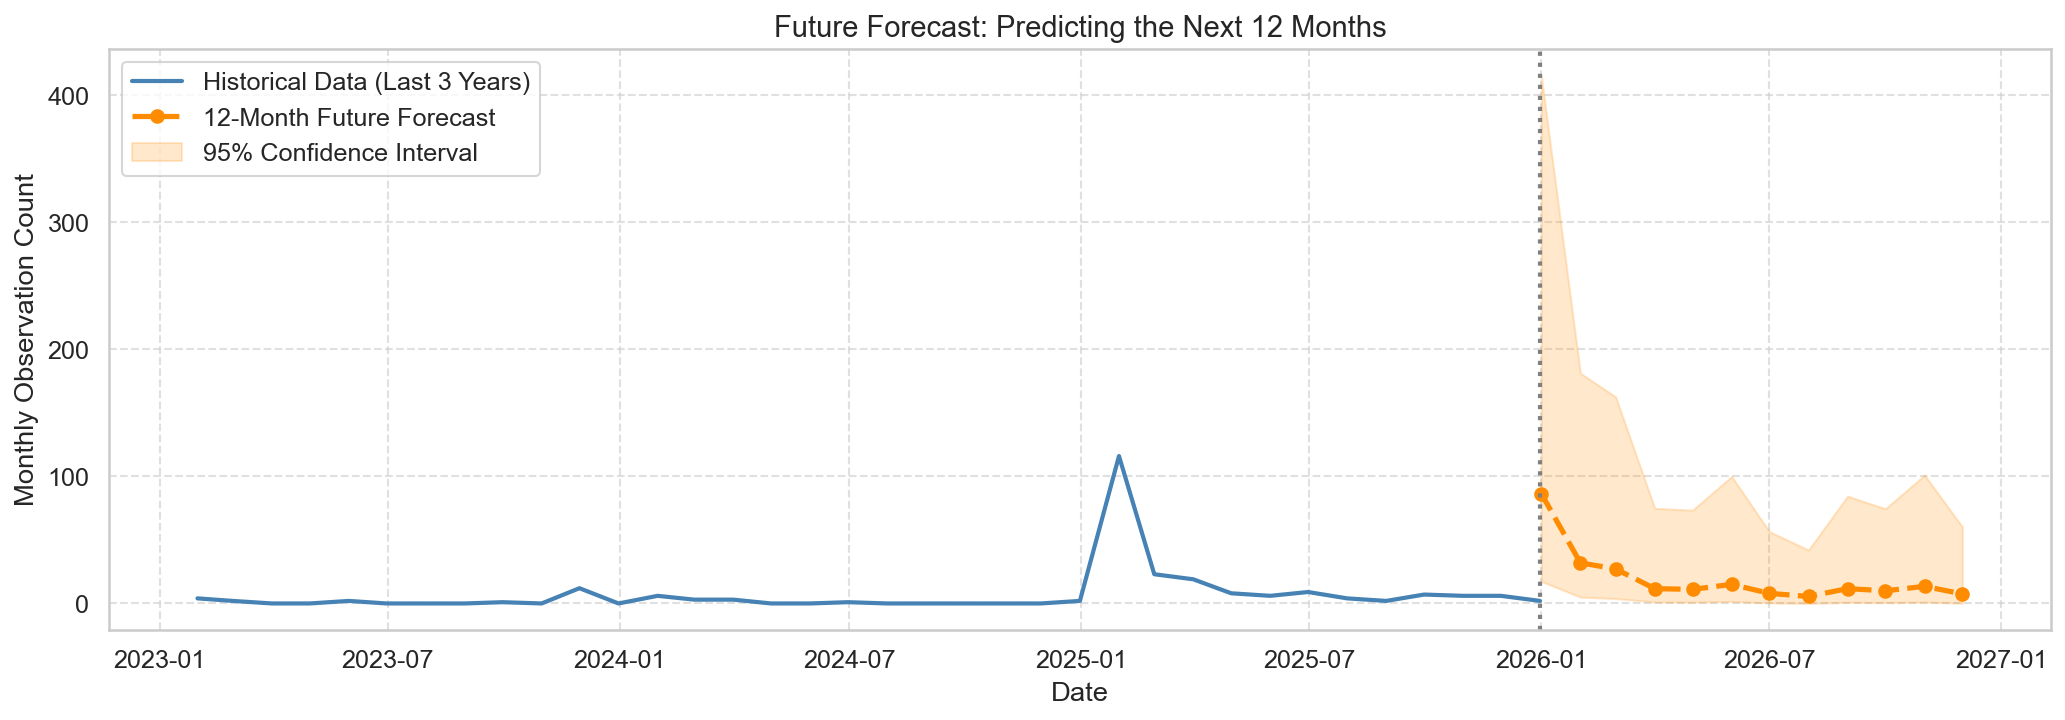

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")

# --------------------------------------------------------------------
# 1. LOAD DATA & AGGREGATE
# --------------------------------------------------------------------
df = pd.read_csv('india_cms_temporal_preprocessed.csv')
df.columns = df.columns.str.strip()
df['event_date'] = pd.to_datetime(df['event_date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['event_date'])

# Aggregate to monthly counts
ts = df.groupby(pd.Grouper(key='event_date', freq='ME')).agg(
    count=('species_scientific_name', 'count')
).reset_index()

ts = ts.set_index('event_date').asfreq('ME')
ts['count'] = ts['count'].fillna(0)
ts = ts.reset_index()

# Log transform to stabilize the variance
ts['log_count'] = np.log1p(ts['count'])

# --------------------------------------------------------------------
# 2. TRAIN-TEST SPLIT (Strict 12-Month Holdout)
# --------------------------------------------------------------------
HOLDOUT = 12
train_size = len(ts) - HOLDOUT
train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print(f"Training Series: {train['event_date'].min().date()} to {train['event_date'].max().date()}")
print(f"Testing Series : {test['event_date'].min().date()} to {test['event_date'].max().date()}\n")

# --------------------------------------------------------------------
# 3. HONEST LINEAR REGRESSION (Trend + Seasonality)
# --------------------------------------------------------------------
ts['time_step'] = np.arange(len(ts))
months_dummies = pd.get_dummies(ts['event_date'].dt.month, prefix='month', drop_first=True)

X_full = pd.concat([ts['time_step'], months_dummies], axis=1)
y_full = ts['log_count']

X_train_lr, y_train_lr = X_full.iloc[:train_size], y_full.iloc[:train_size]
X_test_lr = X_full.iloc[train_size:]

lr_model = LinearRegression().fit(X_train_lr, y_train_lr)
lr_pred_raw = np.expm1(lr_model.predict(X_test_lr))

# --------------------------------------------------------------------
# 4. OPTIMIZED SARIMA (Grid Search)
# --------------------------------------------------------------------
print("Running Grid Search for Optimal SARIMA...")
train_series = ts.set_index('event_date')['log_count'].iloc[:train_size]

best_aic = float("inf")
best_order, best_s_order = None, None

for p, d, q in itertools.product(range(2), range(2), range(2)):
    for P, D, Q in itertools.product(range(2), range(2), range(2)):
        try:
            model = SARIMAX(train_series, order=(p,d,q), seasonal_order=(P,D,Q,12),
                            enforce_stationarity=False, enforce_invertibility=False)
            model_fit = model.fit(disp=False)
            if model_fit.aic < best_aic:
                best_aic, best_order, best_s_order = model_fit.aic, (p,d,q), (P,D,Q,12)
        except:
            continue

print(f"Best SARIMA Order: {best_order} x {best_s_order}")

best_sarima = SARIMAX(train_series, order=best_order, seasonal_order=best_s_order,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_pred_raw = np.expm1(best_sarima.get_forecast(steps=len(test)).predicted_mean.values)

# --------------------------------------------------------------------
# 5. METRICS COMPARISON
# --------------------------------------------------------------------
def print_metrics(model_name, y_true, y_pred):
    print(f"{model_name} -> MAE: {mean_absolute_error(y_true, y_pred):.2f} | RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f} | R²: {r2_score(y_true, y_pred):.4f}")

print("\n--- PERFORMANCE ON UNSEEN 12-MONTH HOLDOUT ---")
print_metrics("Linear Model", test['count'], lr_pred_raw)
print_metrics("SARIMA Model", test['count'], sarima_pred_raw)

# --------------------------------------------------------------------
# 6. PLOT 1: FORECAST COMPARISON (Gap Removed + Red Shaded Window)
# --------------------------------------------------------------------
plt.figure(figsize=(14, 6))

# Connect the training and holdout lines
last_date = train['event_date'].iloc[-1]
last_count = train['count'].iloc[-1]
plot_dates = [last_date] + list(test['event_date'])
plot_actuals = [last_count] + list(test['count'])
plot_lr = [last_count] + list(lr_pred_raw)
plot_sarima = [last_count] + list(sarima_pred_raw)

plt.plot(train['event_date'], train['count'], label='Training Data', color='gray', alpha=0.5)
plt.plot(plot_dates, plot_actuals, label='Actual Holdout (Test)', color='blue', linewidth=2, marker='o')
plt.plot(plot_dates, plot_lr, label='Linear Model Forecast', color='orange', linestyle='--', linewidth=2)
plt.plot(plot_dates, plot_sarima, label='SARIMA Forecast', color='green', linestyle='-.', linewidth=2)

plt.axvspan(test['event_date'].iloc[0], test['event_date'].iloc[-1], color='red', alpha=0.10, label='Inference Window (Holdout)')

plt.title("Temporal Forecasting: Actuals vs Models")
plt.xlabel("Time")
plt.ylabel("Observation Count")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(train['event_date'].iloc[-36], test['event_date'].iloc[-1] + pd.Timedelta(days=15))
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------
# 7. PLOT 2: SARIMA RESIDUAL DIAGNOSTICS
# --------------------------------------------------------------------
residuals = best_sarima.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].plot(residuals.values, color='steelblue', linewidth=1)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0,0].set_title('SARIMA Residuals (log scale)')

axes[0,1].hist(residuals.values, bins=25, color='steelblue', edgecolor='white', density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[0,1].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()), color='darkorange', linewidth=2)
axes[0,1].set_title('Residual Distribution vs Normal PDF')

stats.probplot(residuals.values, dist='norm', plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Checking for Normality)')
axes[1,0].get_lines()[1].set_color('red')

plot_acf(residuals.dropna(), lags=min(20, len(residuals)//2 - 1), ax=axes[1,1], color='steelblue')
axes[1,1].set_title('ACF of Residuals (Checking for White Noise)')

fig.suptitle('SARIMA Residual Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --------------------------------------------------------------------
# 8. PLOT 3: UNKNOWN FUTURE FORECAST (Next 12 Months)
# --------------------------------------------------------------------
full_series = ts.set_index('event_date')['log_count']
full_sarima = SARIMAX(full_series, order=best_order, seasonal_order=best_s_order,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

forecast_obj = full_sarima.get_forecast(steps=12)
future_dates = pd.date_range(ts['event_date'].iloc[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')
future_fc_raw = np.expm1(forecast_obj.predicted_mean.values)
ci_lower = np.expm1(forecast_obj.conf_int(alpha=0.05).iloc[:, 0].values)
ci_upper = np.expm1(forecast_obj.conf_int(alpha=0.05).iloc[:, 1].values)

plt.figure(figsize=(14, 5))
plt.plot(ts['event_date'].iloc[-36:], ts['count'].iloc[-36:], color='steelblue', linewidth=2, label='Historical Data (Last 3 Years)')
plt.plot(future_dates, future_fc_raw, color='darkorange', linewidth=2.5, marker='o', linestyle='--', label='12-Month Future Forecast')
plt.fill_between(future_dates, ci_lower, ci_upper, color='darkorange', alpha=0.2, label='95% Confidence Interval')

plt.axvline(ts['event_date'].iloc[-1], color='grey', linestyle=':', linewidth=2)
plt.title('Future Forecast: Predicting the Next 12 Months', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Monthly Observation Count')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()